# 01 — Descriptive Statistics with `TimeSeries`

This notebook walks through the **Descriptive** mixin of the `statista.time_series.TimeSeries` class. We use **real daily temperature data** (1981 onward) and explain every statistic from scratch, so no prior statistics background is required.

**What you will learn:**
- What *mean*, *median*, and *standard deviation* actually measure.
- How the **extended statistics** (CV, skewness, kurtosis, IQR, MAD) describe the shape and spread of a distribution.
- Why **L-moments** (Hosking, 1990) are often preferred over ordinary moments.
- How to build a publication-ready summary table with `summary()`.

## 1. What are descriptive statistics?

Descriptive statistics are a handful of numbers that summarise a much larger dataset. Three ideas sit at their core:

| Statistic | What it tells you | Analogy |
|-----------|-------------------|---------|
| **Mean**  | Typical value (arithmetic average) | Balance point of a seesaw |
| **Median**| Middle value (50% above, 50% below) | Middle of a queue |
| **Standard deviation** | How spread out the values are | Average distance from the mean |

If you only look at the mean, two very different datasets (one calm, one wild) can look identical. That is why we also need measures of **spread** and **shape**.

## 2. Imports and loading real temperature data

We load a daily temperature record starting 1981-01-01. The file has two columns: `Date` and `Temp` (degrees Celsius).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statista.time_series import TimeSeries

df = pd.read_csv(
    '../../../examples/data/temp.csv',
    parse_dates=['Date'],
    index_col='Date',
)
ts = TimeSeries(df)
print('Shape:', ts.shape)
ts.head()

Shape: (3650, 1)


,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


## 3. `.stats` — the basic 8-row summary

`.stats` simply delegates to `pandas.DataFrame.describe()`. It returns the following rows:

- **count** — number of non-missing values.
- **mean**  — arithmetic average.
- **std**   — sample standard deviation.
- **min / max** — extremes.
- **25% / 50% / 75%** — quartiles. The 50% row is the median.

The three quartiles split the data into four equal-sized groups.

In [2]:
basic = ts.stats
print(basic)

              Temp
count  3650.000000
mean     11.177753
std       4.071837
min       0.000000
25%       8.300000
50%      11.000000
75%      14.000000
max      26.300000


**What this means for your data.** The mean (around 11.18 C) and the median (11.00 C) are very close, suggesting the temperature distribution is roughly symmetric. The minimum is 0 C and the maximum is 26.3 C, giving a sense of the full range over ~10 years of daily values.

## 4. `.extended_stats` — shape and robust spread

`extended_stats` adds 9 more rows to the basic table. The new ideas are:

### Coefficient of variation (CV)
`CV = std / mean`. It is a *unit-free* measure of relative spread. A CV of 0.1 means the standard deviation is 10% of the mean. Useful for comparing variability across datasets with different units or scales.

### Skewness
Skewness measures asymmetry of the distribution.

- **Skewness = 0** — perfectly symmetric (e.g., a normal distribution).
- **Skewness > 0** — a long *right* tail (a few very large values, e.g., flood peaks).
- **Skewness < 0** — a long *left* tail (a few very small values).

### Kurtosis (excess kurtosis)
Kurtosis tells you how *heavy* the tails are compared to a normal distribution.

- **Kurtosis = 0** — same tail weight as a normal distribution.
- **Kurtosis > 0** — heavy tails, more extreme values than the normal (leptokurtic).
- **Kurtosis < 0** — light tails, fewer extremes (platykurtic).

### IQR and MAD — robust measures of spread
- **IQR** = 75th percentile - 25th percentile. Measures the spread of the *middle half* of the data. Ignores extremes.
- **MAD** (median absolute deviation) = median of `|x - median|`. It is much less sensitive to outliers than the standard deviation, because a single crazy value can inflate `std` but cannot move the median far.

In [3]:
ext = ts.extended_stats
print(ext)

                 Temp
count     3650.000000
mean        11.177753
std          4.071837
cv           0.364280
skewness     0.172283
kurtosis    -0.063105
min          0.000000
5%           4.800000
10%          6.090000
25%          8.300000
50%         11.000000
75%         14.000000
90%         16.300000
95%         17.855000
max         26.300000
iqr          5.700000
mad          2.800000


**What this means for your data.**
- CV ~ 0.36 — temperature varies by about 36% of its mean value; fairly variable.
- Skewness ~ 0.17 — very mild right skew (slightly more hot extremes than cold).
- Kurtosis ~ -0.06 — tails essentially identical to a normal distribution.
- MAD (2.8 C) is smaller than std (4.07 C). This is normal: MAD under-estimates std for normal-like data by design, but it is far more robust to occasional outliers.

## 5. `.l_moments()` — robust alternatives to moments

**L-moments** (Hosking, 1990) are calculated from ordered (sorted) data rather than from powers of the data. They have three big advantages:

1. **Much more robust to outliers.** Ordinary skewness uses cubes, so a single extreme value dominates it. L-skewness is bounded between -1 and +1.
2. **Work well on small samples.** This matters a lot in hydrology where you may only have 30 annual flood peaks.
3. **Excellent for distribution identification.** L-skewness vs. L-kurtosis plots let you pick the best-fitting distribution (Gumbel, GEV, log-normal, ...) visually.

Returned rows:

- `L1` — L-location (equals the ordinary mean).
- `L2` — L-scale (robust spread).
- `t`  — L-CV = L2/L1 (robust CV).
- `t3` — L-skewness.
- `t4` — L-kurtosis.
- `t5` — higher order ratio (rarely interpreted).

In [4]:
lm = ts.l_moments(nmom=5)
print(lm)

         Temp
L1  11.177753
L2   2.301612
t    0.205910
t3   0.011727
t4   0.048175
t5   0.004162


**What this means for your data.**
- `L1 = 11.18 C` matches the ordinary mean exactly — L-moments are calibrated this way.
- `t3` (L-skewness) ~ 0.012 — almost perfectly symmetric. Contrast this with the ordinary skewness of 0.17 — L-skewness gives a much cleaner picture when the tails are slightly noisy.
- `t4` (L-kurtosis) ~ 0.048 — tails a tiny bit heavier than normal. This would place the distribution close to the Gumbel / normal area of the L-moment diagram.

## 6. `.summary()` — the paper-ready Table 1

`.summary()` combines the most useful rows of `extended_stats` with the three L-moment ratios into a **13-row** table. This is the kind of table you put at the top of a paper's methods or study-area section.

In [5]:
sm = ts.summary()
print(sm)

                   Temp
count       3650.000000
mean          11.177753
std            4.071837
cv             0.364280
skewness       0.172283
kurtosis      -0.063105
min            0.000000
max           26.300000
iqr            5.700000
mad            2.800000
L-CV           0.205910
L-skewness     0.011727
L-kurtosis     0.048175


## 7. Quick visual sanity check

Plotting the raw data makes the statistics easier to interpret. We can clearly see the annual seasonal cycle — that seasonality is *why* the standard deviation is fairly large while the skewness is near zero (the distribution is roughly symmetric around an annual mean).

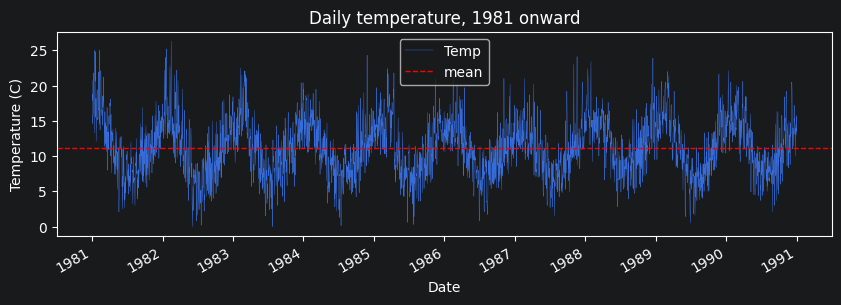

In [6]:
fig, ax = plt.subplots(figsize=(10, 3))
ts['Temp'].plot(ax=ax, linewidth=0.3)
ax.set_title('Daily temperature, 1981 onward')
ax.set_ylabel('Temperature (C)')
ax.axhline(ts.stats.loc['mean', 'Temp'], color='red', linestyle='--', linewidth=1, label='mean')
ax.legend()
plt.show()

## 8. Summary

In this notebook you met the core descriptive tools of `TimeSeries`:

| Method | Purpose |
|--------|---------|
| `.stats` | 8-row pandas `describe()` |
| `.extended_stats` | 17-row table with CV, skewness, kurtosis, percentiles, IQR, MAD |
| `.l_moments(nmom=...)` | Robust moment ratios (Hosking, 1990) |
| `.summary()` | 13-row paper-ready combined table |

**Rule of thumb.** If your data has outliers or a small sample size, trust L-moments and MAD over ordinary moments and standard deviation.

**Reference.** Hosking, J. R. M. (1990). *L-moments: Analysis and estimation of distributions using linear combinations of order statistics.* JRSS B, 52(1), 105-124.